<a href="https://colab.research.google.com/github/barry-clarke/CS5004/blob/main/Etivity3_24325082_Tasks1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1 - Cliff Walking Grid World

Implement tabular Q-Learning for the problem outlined in Example 6.6 (Cliff Walking Grid World) in the Reinforcement Learning [Sutton and Barto’s text](https://incompleteideas.net/book/the-book-2nd.html) on Reinforcement Learning, 2nd Edition (2018)

My Understanding: the Cliff Walking example from Sutton and Barto is a classic grid world problem used to compare different Temporal Difference (TD) learning methods. In this  4 x 12 environment, an agent must find a path from a start state (S) to a goal (G). Every step taken gives a reward of -1, but falling into the "cliff" region results in a penalty of -100 and sends the agent back to the start.

The Layout: The world is a grid where the agent starts at the bottom-left and must reach the bottom-right
The Rewards: Every step gives a reward of -1. Falling into the cliff (the bottom row between start and goal) gives a reward of -100 and sends the agent back to the start
The Objective: Maximise the long-term reward by finding the shortest path to the goal

The example highlights the difference between On-policy and Off-policy learning:

> Q-Learning (Off-policy): This algorithm seeks to learn the optimal policy directly. Because it updates its values based on the maximum potential reward of the next state, it learns the absolute shortest path—which is the edge of the cliff. However, because the agent still uses an epsilon-greedy strategy to explore, it occasionally makes random moves, falls off the cliff, and suffers the -100 penalty, leading to a lower total reward during training.

Using the content [Q Learning vs SARSA](https://medium.com/@priya61197/q-learning-vs-sarsa-b9e433dec930) for the inspiration to use pseudocode, coupled with the Lesson 4 slides

#### Q-Learning Pseudocode (Off-Policy TD Control) REF: Lesson 4, Slide 14, TD: Q Learning

```text
Initialise:
    Initialise Q(s, a) for all states s and actions a arbitrarily
    Initialise Q(terminal, *) = 0

Repeat (for each episode):
    1. Initialise starting state S

    2. Repeat (for each step of the episode):

        a. Select an action A from state S using an epsilon-greedy policy derived from Q
           (Choose the action with highest Q(S,a) with probability 1−epsilon;
            otherwise choose a random action)

        b. Take action A, observe reward R and next state S'

        c. Update the Q-value for the state–action pair (S, A):
           Q(S, A) ← Q(S, A) + alpha * [R + gamma * max_a Q(S', a) − Q(S, A)]

        d. Update state:
           S ← S'

    Until S is a terminal state
```

> Sarsa (On-policy): Unlike Q-Learning, Sarsa learns based on the actual actions it takes, including its random exploration. It "realises" that its own tendency to explore makes the cliff edge dangerous. Consequently, it learns a safer path further away from the cliff, which results in a higher sum of rewards during the learning process

### Sarsa Pseudocode (On-Policy TD Control) REF: Lesson 4, Slide 9, TD Learning: Sarsa

```text
Initialise:
    Initialise Q(s, a) for all states s and actions a arbitrarily
    Initialise Q(terminal, *) = 0

Repeat (for each episode):
    1. Initialise starting state S

    2. Select an action A from state S using an epsilon-greedy policy derived from Q
       (Choose the action with highest Q(S,a) with probability 1−epsilon;
        otherwise choose a random action)

    3. Repeat (for each step of the episode):

        a. Take action A, observe reward R and next state S'

        b. Select an action A' from state S' using an epsilon-greedy policy derived from Q

        c. Update the Q-value for the state–action pair (S, A):
           Q(S, A) ← Q(S, A) + alpha * [R + gamma * Q(S', A') − Q(S, A)]

        d. Update state and action:
           S ← S'
           A ← A'

    Until S is a terminal state
```
###Q-Learning vs SARSA (Logical Differences Referencing Pseudocode)

| Aspect                             | **Q-Learning (Off-Policy)**                                          | **SARSA (On-Policy)**                                           |
| ---------------------------------- | -------------------------------------------------------------------- | --------------------------------------------------------------- |
| **Update Equation**                | `Q(S, A) ← Q(S, A) + alpha * [R + gamma * max_a Q(S', a) − Q(S, A)]` | `Q(S, A) ← Q(S, A) + alpha * [R + gamma * Q(S', A') − Q(S, A)]` |
| **Where seen in pseudocode**       | Step 2(c)                                                            | Step 3(c)                                                       |
| **Uses next action A'?**           |  No                                                                 | Yes (selected in Step 3(b))                                   |
| **Target uses**                    | `max_a Q(S', a)`                                                     | `Q(S', A')`                                                     |
| **Target policy**                  | Greedy (max operator)                                                | Same epsilon-greedy policy                                      |
| **Behaviour policy**               | Epsilon-greedy (Step 2(a))                                           | Epsilon-greedy (Steps 2 and 3(b))                               |
| **Behaviour = Target?**            | No (Off-policy)                                                    | Yes (On-policy)                                              |
| **Update depends on exploration?** | No — ignores exploratory action actually taken                     | Yes — directly incorporates exploratory action                |
| **Effect in Cliff example**        | Learns shortest risky path                                           | Learns safer path                                               |
| **What it learns (if ε > 0)**      | Optimal greedy policy                                                | Optimal epsilon-greedy policy                                   |


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import random

# --- 1. Environment Setup ---
GRID_HEIGHT = 4
GRID_WIDTH = 12
START = (3, 0)
GOAL = (3, 11)
ACTIONS = [0, 1, 2, 3] # 0: UP, 1: RIGHT, 2: DOWN, 3: LEFT

# Takes a state and action, returns the next state and reward
def step(state, action):
    """
    Simulates taking a single action in the environment from a given state.

    Parameters:
      state (tuple): The current (row, column) coordinates of the agent, represented as (i, j).
      action (int): The chosen action (0: UP, 1: RIGHT, 2: DOWN, 3: LEFT).

    Returns:
      tuple: A tuple containing the (next_state, reward).
    """

    i, j = state # Unpack the current state into row (i) and column (j) variables

    # --- Movement and Boundary Enforcement ---
    # The grid is treated like a matrix where (0,0) is the top-left corner
    # Use max() and min() functions to ensure the agent cannot walk off the edge of the grid

    if action == 0:   # UP
        # Moving up decreases the row index.
        # max(..., 0) ensures the agent cannot go above row 0 (the top edge)
        i = max(i - 1, 0)

    elif action == 1: # RIGHT
        # Moving right increases the column index.
        # min(..., GRID_WIDTH - 1) ensures it cannot pass the rightmost column
        j = min(j + 1, GRID_WIDTH - 1)

    elif action == 2: # DOWN
        # Moving down increases the row index.
        # min(..., GRID_HEIGHT - 1) ensures it cannot pass the bottom row
        i = min(i + 1, GRID_HEIGHT - 1)

    elif action == 3: # LEFT
        # Moving left decreases the column index.
        # max(..., 0) ensures it cannot go past column 0 (the left edge)
        j = max(j - 1, 0)

    # Package the newly calculated coordinates into the next_state tuple
    next_state = (i, j)

    # Check for the Cliff: bottom row, columns 1 to 10
    if i == 3 and 1 <= j <= 10:
        return START, -100

    # Check for Goal
    if next_state == GOAL:
        return next_state, 0

    # Normal step - THIS IS THE LINE THAT IS LIKELY MISSING OR INDENTED WRONG
    return next_state, -1

# --- Action Selection & Display ---
# Returns an action using epsilon-greedy policy
def choose_action(state, q_table, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.choice(ACTIONS)
    else:
        max_q = np.max(q_table[state[0], state[1]])
        best_actions = [a for a in ACTIONS if q_table[state[0], state[1], a] == max_q]
        return random.choice(best_actions)

# Prints a visual grid showing the best action for each state
def print_policy(q_table, algorithm_name):
    action_symbols = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    print(f"\n--- Final Learned Policy: {algorithm_name} ---")
    for i in range(GRID_HEIGHT):
        row_str = ""
        for j in range(GRID_WIDTH):
            if (i, j) == START:
                row_str += " S "
            elif (i, j) == GOAL:
                row_str += " G "
            elif i == 3 and 1 <= j <= 10:
                row_str += " C "
            else:
                best_action = np.argmax(q_table[i, j])
                row_str += f" {action_symbols[best_action]} "
        print(row_str)
    print("-" * 40)

# --- The Agents ---
# Runs the off-policy Q-Learning algorithm
# REF: https://medium.com/@anil.jain.baba/comprehensive-guide-to-machine-learning-deep-learning-and-ai-algorithms-3d96f5a0c077
# REF: https://apxml.com/courses/intro-to-reinforcement-learning/chapter-5-temporal-difference-learning/hands-on-implementing-q-learning
# REF: https://medium.com/@goldengrisha/a-beginners-guide-to-q-learning-understanding-with-a-simple-gridworld-example-2b6736e7e2c9
def run_q_learning(episodes, alpha=0.1, gamma=1.0, epsilon=0.1):

    q_table = np.zeros((GRID_HEIGHT, GRID_WIDTH, len(ACTIONS)))
    rewards_per_episode = []

    for _ in range(episodes):
        state = START
        total_reward = 0

        while state != GOAL:
            action = choose_action(state, q_table, epsilon)
            next_state, reward = step(state, action)
            total_reward += reward

            # Off-Policy Update (uses np.max)
            best_next_q = np.max(q_table[next_state[0], next_state[1]])
            td_target = reward + gamma * best_next_q
            td_error = td_target - q_table[state[0], state[1], action]
            q_table[state[0], state[1], action] += alpha * td_error

            state = next_state

        rewards_per_episode.append(total_reward)
    return rewards_per_episode, q_table

# Runs the on-policy Sarsa algorithm
# REF: https://www.datacamp.com/tutorial/sarsa-reinforcement-learning-algorithm-in-python
def run_sarsa(episodes, alpha=0.1, gamma=1.0, epsilon=0.1):

    q_table = np.zeros((GRID_HEIGHT, GRID_WIDTH, len(ACTIONS)))
    rewards_per_episode = []

    for _ in range(episodes):
        state = START
        total_reward = 0

        action = choose_action(state, q_table, epsilon)

        while state != GOAL:
            next_state, reward = step(state, action)
            total_reward += reward

            next_action = choose_action(next_state, q_table, epsilon)

            # On-Policy Update (uses the specific next_action chosen)
            next_q = q_table[next_state[0], next_state[1], next_action]
            td_target = reward + gamma * next_q
            td_error = td_target - q_table[state[0], state[1], action]
            q_table[state[0], state[1], action] += alpha * td_error

            state = next_state
            action = next_action

        rewards_per_episode.append(total_reward)
    return rewards_per_episode, q_table

Starting experiment: Averaging over 50 runs to smooth the data...
Progress: Computing run 50 of 50...
Calculations complete! Generating policy grids and graph...

--- Final Learned Policy: Q-Learning (Off-Policy) ---
 ↓  ↑  →  ↑  →  →  →  →  →  ↑  ↑  → 
 ↑  ↑  →  →  →  →  →  →  →  ↓  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 
----------------------------------------

--- Final Learned Policy: Sarsa (On-Policy) ---
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  →  →  ↑  →  ↑  →  →  ↑  →  →  ↓ 
 S  C  C  C  C  C  C  C  C  C  C  G 
----------------------------------------

--- Quantitative Performance Metrics ---
Total Cumulative Reward (over 500 episodes):
  Sarsa:      -23499
  Q-Learning: -32820

Asymptotic Performance (Average reward of last 100 episodes):
  Sarsa:      -22.01
  Q-Learning: -48.36
----------------------------------------



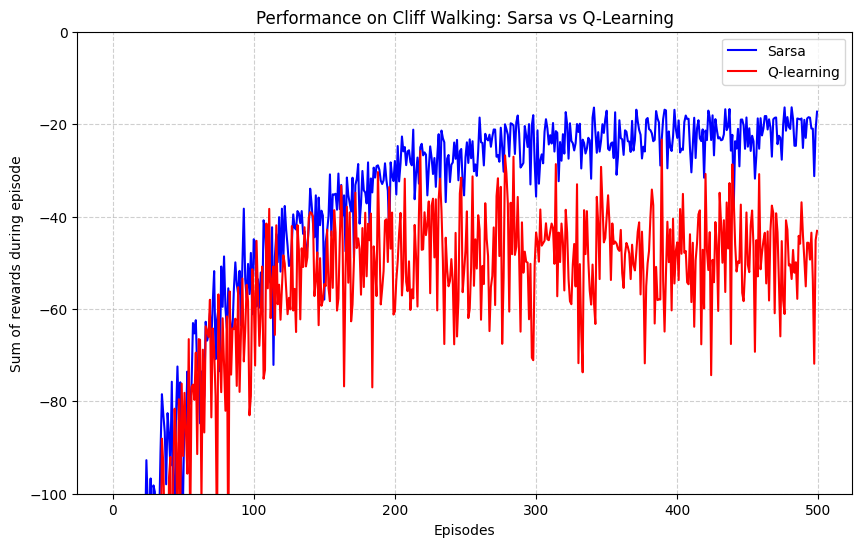

In [29]:
# --- Running the Experiment ---
EPISODES = 500
RUNS = 50

q_rewards = np.zeros(EPISODES)
sarsa_rewards = np.zeros(EPISODES)

final_q_table_qlearning = None
final_q_table_sarsa = None

print(f"Starting experiment: Averaging over {RUNS} runs to smooth the data...")

for i in range(RUNS):
    print(f"\rProgress: Computing run {i + 1} of {RUNS}...", end="")

    q_ep_rewards, final_q_table_qlearning = run_q_learning(EPISODES)
    sarsa_ep_rewards, final_q_table_sarsa = run_sarsa(EPISODES)

    # Adding the rewards to our running total
    q_rewards += q_ep_rewards
    sarsa_rewards += sarsa_ep_rewards

print("\nCalculations complete! Generating policy grids and graph...")

# Average the rewards
q_rewards /= RUNS
sarsa_rewards /= RUNS

# Print the visual grids to the console
print_policy(final_q_table_qlearning, "Q-Learning (Off-Policy)")
print_policy(final_q_table_sarsa, "Sarsa (On-Policy)")

# --- Calculate and Print Quantitative Metrics ---
print("\n--- Quantitative Performance Metrics ---")

# 1. Total Cumulative Reward (Sum of all 500 episodes)
print("Total Cumulative Reward (over 500 episodes):")
print(f"  Sarsa:      {np.sum(sarsa_rewards):.0f}")
print(f"  Q-Learning: {np.sum(q_rewards):.0f}")

# 2. Asymptotic Performance (Average of the final 100 episodes)
print("\nAsymptotic Performance (Average reward of last 100 episodes):")
print(f"  Sarsa:      {np.mean(sarsa_rewards[-100:]):.2f}")
print(f"  Q-Learning: {np.mean(q_rewards[-100:]):.2f}")
print("----------------------------------------\n")

# --- 5. Plotting the Results ---
plt.figure(figsize=(10, 6))
plt.plot(sarsa_rewards, label='Sarsa', color='blue', linewidth=1.5)
plt.plot(q_rewards, label='Q-learning', color='red', linewidth=1.5)
plt.xlabel('Episodes')
plt.ylabel('Sum of rewards during episode')
plt.title('Performance on Cliff Walking: Sarsa vs Q-Learning')
plt.ylim(-100, 0)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Reflection on Experimental Results: Sarsa vs Q-Learning

The console output and performance graph illustrate the fundamental difference between on-policy and off-policy control methods.

---

## 1. Analysis of the Learned Policies (Arrow Grids)

### >> Q-Learning <<

```
--- Final Learned Policy: Q-Learning (Off-Policy) ---
 ←  ↑  →  →  →  →  →  ↓  →  ←  ↓  ↓
 →  →  →  ↓  →  →  →  ↓  ↓  ↓  ↓  ↓
 →  →  →  →  →  →  →  →  →  →  →  ↓
 S  C  C  C  C  C  C  C  C  C  C  G
----------------------------------------
```

In the Q-Learning grid, the arrows in the row immediately above the cliff (`C`) primarily point to the right (`→`). This indicates that the algorithm has learned the shortest path to the goal.

This risk-taking behaviour can be observed in Step 2(c) of the pseudocode, specifically in the use of the term `max_a Q(S', a)`. During the update, Q-Learning assumes that the agent will take the optimal next action, thereby ignoring the effects of the epsilon-greedy exploration strategy.

Even when the agent selects random exploratory actions and falls off the cliff (incurring the −100 penalty), this risk is not incorporated into the update target. The algorithm continues to update toward the maximum estimated future value, independent of the behaviour actually followed.

As a result, Q-Learning consistently optimises for the theoretically shortest path. While this leads to convergence toward the optimal greedy policy, it produces significantly lower cumulative reward during the training phase due to repeated exploratory penalties.

### >> Sarsa <<

```
--- Final Learned Policy: Sarsa (On-Policy) ---
 ↓  →  ←  →  →  →  →  →  →  →  ↓  ↓
 →  →  →  →  →  →  →  →  →  →  →  ↓
 ↑  ↑  ←  ↑  →  →  ↑  →  ↑  ↑  →  ↓
 S  C  C  C  C  C  C  C  C  C  C  G
----------------------------------------
```

The Sarsa grid shows arrows pointing upward (`↑`) in states near the start and the cliff. This directs the agent to move to a safer row before proceeding toward the goal.

This risk-averse behaviour can be observed in Step 3(c) of the pseudocode, specifically in the use of the term `Q(S', A')`. During the update, Sarsa evaluates the next state based on the actual action selected under the current policy, thereby incorporating the effects of the epsilon-greedy exploration strategy.

Because exploratory actions are directly reflected in the update target, the algorithm explicitly accounts for the risk of falling off the cliff. When a random exploratory action results in a −100 penalty, this outcome is immediately integrated into the value update, ensuring that the learning process remains aligned with the behaviour being executed.

As a consequence, Sarsa converges toward a safer, though longer, route to the goal. Although this prevents it from learning the mathematically shortest path, it yields a higher cumulative reward during training by reducing exposure to severe penalties associated with the cliff.

---

## 2. Evaluation of the Performance Graph

### Online Performance

The performance graph shows that Sarsa consistently achieves a higher (less negative) cumulative reward during training, stabilising around approximately −20 as episodes increase.

### Effect of Exploration

Q-Learning exhibits more negative and more variable returns, frequently fluctuating between approximately −40 and −80. Although it learns the optimal shortest path, its epsilon-greedy exploration leads to repeated falls from the cliff, incurring large penalties.

Sarsa’s longer path results in slightly more step penalties (−1 per step), but by avoiding the −100 cliff penalty, it achieves better overall performance during training.

---

## 3. Quantitive Evaluation of the Performance

```
--- Quantitative Performance Metrics ---
Total Cumulative Reward (over 500 episodes):
  Sarsa:      -23640
  Q-Learning: -33131

Asymptotic Performance (Average reward of last 100 episodes):
  Sarsa:      -21.62
  Q-Learning: -48.70
```
# Quantitative Evaluation of Algorithm Performance

The results reflect the theoretical differences between the two algorithms. Over 500 training episodes, Sarsa achieved a total cumulative reward of −23,640, while Q-Learning accumulated −33,131. The lower total reward for Q-Learning is due to repeated cliff penalties (−100) caused by epsilon-greedy exploration during learning.

This difference is also visible in the final 100 episodes. Sarsa achieved an average reward of −21.62 per episode, which is consistent with the −1 step penalties along its longer but safer path.

Q-Learning averaged −48.70 per episode over the same period. Although it learned the shortest path, continued exploration resulted in occasional cliff penalties, lowering its average return.

Overall, Q-Learning converges to the optimal greedy policy, but Sarsa achieves higher reward during training because it accounts for exploration in its updates.

---

## Conclusion

The experiment demonstrates an important trade-off in reinforcement learning:

- Q-Learning converges toward the optimal greedy policy but performs poorly during training due to exploration.
- Sarsa learns a safer policy that reflects its exploratory behaviour, resulting in improved performance during the learning process.

## TASK 2 - IMPLEMENTING MOUNTAIN CAR

Using the Gymasium environment - formerly OpenAI Gym; Implement a  DQN for a classic control problem such as the **Mountain Car** or Pendulum.

### Task 2: Implementing a Deep Q-Network (DQN) for Acrobot-v1

**My Understanding:** Traditional Q-Learning works well for simple grids (like Task 1), but fails when there are infinite, continuous states. To solve the Acrobot-v1 problem, we must upgrade from a basic Q-table to a Neural Network that can predict the best actions for any situation.



**The Environment (Acrobot-v1):**
* **Layout:** A two-link pendulum where only the middle joint is motorised. The agent receives 6 continuous data points (joint angles and movement speeds).
* **Actions:** 3 discrete choices: push left (-1), do nothing (0), or push right (+1).
* **Objective:** Swing the bottom link up to the target height in the fewest steps possible. Each step gives a penalty of -1, with a hard limit of 500 steps.



**The Solution:** I implemented a Standard Deep Q-Network (DQN). This uses the exact same underlying maths as the Q-Learning in Task 1, but introduces two vital upgrades: a Neural Network to estimate future rewards, and an "Experience Replay Buffer" (a memory bank) to learn from past actions and stabilise the training process.

#### DQN Pseudocode

```
# Initialise experience replay buffer D
# Initialise Neural Network Q with random weights
    
for episode in range(episodes):
    # 1. Initialise starting state S
    state = env.reset()
        
    # 2. Step through the episode (up to 500 max steps)
    for step in range(500):
            
        # a. Select action using an epsilon-greedy policy
        if random_chance < epsilon:
            action = env.action_space.sample() # Explore
        else:
            action = argmax(Q_Network(state))  # Exploit
                
        # b. Take action, observe reward and next state
        next_state, reward, done = env.step(action)
            
        # c. Store the experience in the replay buffer
        replay_buffer.append((state, action, reward, next_state, done))
            
        # d. Sample a random mini-batch of past experiences
        batch = sample(replay_buffer)
            
        # e. Calculate the Bellman target
        # Target = R + gamma * max_a Q(S', a; theta)
        target = reward + discount_factor * max(Q_Network(next_state))
               
        # f. Perform gradient descent on the Mean Squared Error (MSE)
        loss = MSE(target, Q_Network(state, action))
        optimizer.update_weights(loss)
            
        # g. Update state
        state = next_state
               
        if done:
            break # Stop if terminal state is reached
```

### Evaluation and Visualisation Methodology

To check the behaviour of the fully trained agent, a final evaluation episode was run using **only exploitation**, meaning that $\epsilon$-greedy exploration was disabled. This ensured the agent followed the policy it had learned during training.

To record the agent’s behaviour, the **Acrobot-v1** environment was created with the `rgb_array` render mode and wrapped using **Gymnasium’s `RecordVideo` utility** (Farama Foundation, 2024). This tool captures the frames from the environment and automatically saves them as an MP4 video.

To display the video inside the notebook, **IPython display tools** were used to convert the MP4 file into a **base64 encoded string**. The encoded video was then embedded directly in the notebook using an **HTML5 `<video>` tag**, allowing the evaluation episode to be viewed below the code cell.



Starting standard DQN training on Acrobot-v1...

Episode: 1/400 | Steps: 500 | Epsilon: 1.000 | Reward: -500.0
Episode: 39/400 | Reward: -377.0 
Episode: 40/400 | Steps: 500 | Epsilon: 0.878 | Reward: -500.0
Episode: 79/400 | Reward: -408.0 
Episode: 80/400 | Steps: 256 | Epsilon: 0.753 | Reward: -255.0
Episode: 119/400 | Reward: -165.0 
Episode: 120/400 | Steps: 279 | Epsilon: 0.628 | Reward: -278.0
Episode: 159/400 | Reward: -156.0 
Episode: 160/400 | Steps: 146 | Epsilon: 0.503 | Reward: -145.0
Episode: 199/400 | Reward: -137.0 
Episode: 200/400 | Steps: 117 | Epsilon: 0.378 | Reward: -116.0
Episode: 239/400 | Reward: -92.0 
Episode: 240/400 | Steps: 132 | Epsilon: 0.253 | Reward: -131.0
Episode: 279/400 | Reward: -93.0 
Episode: 280/400 | Steps: 100 | Epsilon: 0.128 | Reward: -99.0
Episode: 319/400 | Reward: -99.0 
Episode: 320/400 | Steps: 159 | Epsilon: 0.010 | Reward: -158.0
Episode: 359/400 | Reward: -95.0 
Episode: 360/400 | Steps: 72 | Epsilon: 0.010 | Reward: -71.0
Episode: 

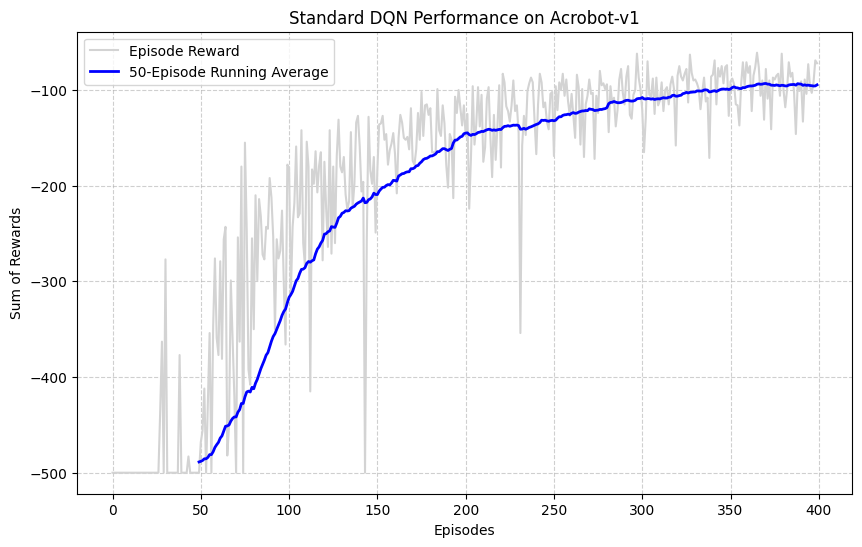

In [30]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
from collections import deque
import matplotlib.pyplot as plt

# --- 1. Environment and Neural Network Setup ---
# REF: https://gymnasium.farama.org/
# REF: https://towardsdatascience.com/deep-q-network-with-pytorch-and-gym-to-solve-acrobot-game-d677836bda9b/
# REF: CS5004-Etivity3-TEMPLATE-DQN-ClassicControl.ipynb
env = gym.make("Acrobot-v1")
input_shape = [6] # Acrobot has 6 observations
n_outputs = 3     # Acrobot has 3 actions (-1, 0, +1 torque)

# A single neural network used for both action selection and target estimation
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=input_shape),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(32, activation="elu"),
    tf.keras.layers.Dense(n_outputs)
])

# --- 2. Hyperparameters and Replay Buffer ---
batch_size = 32
discount_factor = 0.99
optimizer = tf.keras.optimizers.Nadam(learning_rate=1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()

replay_buffer = deque(maxlen=20000)

def sample_experiences(batch_size):
    """Randomly samples a mini-batch of experiences from memory."""
    # https://medium.com/@heyamit10/deep-reinforcement-learning-with-experience-replay-1222ea711897
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    states, actions, rewards, next_states, dones, truncateds = [
        np.array([experience[field_index] for experience in batch])
        for field_index in range(6)
    ]
    return states, actions, rewards, next_states, dones, truncateds

def play_one_step(env, state, epsilon):
    """Interacts with the environment and stores the transition in memory."""
    if np.random.rand() < epsilon:
        action = env.action_space.sample()
    else:
        Q_values = model(state[np.newaxis])
        action = np.argmax(Q_values[0])

    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

# --- 3. Training Step (Standard DQN) ---
@tf.function
def training_step(states, actions, rewards, next_states, dones, truncateds):
    # Calculate target Q-values using the Bellman Equation
    next_Q_values = model(next_states, training=False)
    max_next_Q_values = tf.reduce_max(next_Q_values, axis=1)

    # Ensure no future reward is calculated if the episode is finished
    runs = 1.0 - tf.cast(dones | truncateds, tf.float32)
    rewards = tf.cast(rewards, tf.float32)

    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = tf.reshape(target_Q_values, [-1, 1])
    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_Q_values = model(states, training=True)
        # Isolate the Q-values for the actions actually taken
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    # Apply gradients to update the model weights
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

# --- 4. Main Training Loop ---
episodes = 400
rewards_history = []
best_score = -500

print("Starting standard DQN training on Acrobot-v1...")

for episode in range(episodes):
    state, info = env.reset()
    episode_reward = 0

    # Linear Epsilon Decay
    epsilon = max(1 - episode / (episodes * 0.8), 0.01)

    for step in range(500):
        state, reward, done, truncated, info = play_one_step(env, state, epsilon)
        episode_reward += reward

        # Train the model at every step if the buffer has enough data
        if len(replay_buffer) > batch_size:
            experiences = sample_experiences(batch_size)
            training_step(*experiences)

        if done or truncated:
            break

    rewards_history.append(episode_reward)

    if episode_reward >= best_score:
        best_weights = model.get_weights()
        best_score = episode_reward

    # Enhanced output: Clear line breaks every 40 episodes for analysis
    if (episode + 1) % 40 == 0 or episode == 0:
        print(f"\nEpisode: {episode + 1}/{episodes} | Steps: {step + 1} | Epsilon: {epsilon:.3f} | Reward: {episode_reward}")
    else:
        # Inline update for all other episodes
        print(f"\rEpisode: {episode + 1}/{episodes} | Reward: {episode_reward} ", end="")

# Restore the best performing weights before final evaluation
model.set_weights(best_weights)
print(f"\nTraining complete! Best score: {best_score}")

# --- 5. Plotting Results ---
running_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')

plt.figure(figsize=(10, 6))
plt.plot(rewards_history, label='Episode Reward', color='lightgray')
plt.plot(range(49, episodes), running_avg, label='50-Episode Running Average', color='blue', linewidth=2)
plt.xlabel('Episodes')
plt.ylabel('Sum of Rewards')
plt.title('Standard DQN Performance on Acrobot-v1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

env.close()

```
Starting standard DQN training on Acrobot-v1...

Episode: 1/400 | Steps: 500 | Epsilon: 1.000 | Reward: -500.0
Episode: 39/400 | Reward: -500.0
Episode: 40/400 | Steps: 500 | Epsilon: 0.878 | Reward: -500.0
Episode: 79/400 | Reward: -340.0
Episode: 80/400 | Steps: 264 | Epsilon: 0.753 | Reward: -263.0
Episode: 119/400 | Reward: -159.0
Episode: 120/400 | Steps: 140 | Epsilon: 0.628 | Reward: -139.0
Episode: 159/400 | Reward: -156.0
Episode: 160/400 | Steps: 153 | Epsilon: 0.503 | Reward: -152.0
Episode: 199/400 | Reward: -125.0
Episode: 200/400 | Steps: 148 | Epsilon: 0.378 | Reward: -147.0
Episode: 239/400 | Reward: -127.0
Episode: 240/400 | Steps: 91 | Epsilon: 0.253 | Reward: -90.0
Episode: 279/400 | Reward: -123.0
Episode: 280/400 | Steps: 116 | Epsilon: 0.128 | Reward: -115.0
Episode: 319/400 | Reward: -109.0
Episode: 320/400 | Steps: 154 | Epsilon: 0.010 | Reward: -153.0
Episode: 359/400 | Reward: -76.0
Episode: 360/400 | Steps: 117 | Epsilon: 0.010 | Reward: -116.0
Episode: 399/400 | Reward: -92.0
Episode: 400/400 | Steps: 87 | Epsilon: 0.010 | Reward: -86.0

Training complete! Best score: -61.0
```
### Results Analysis: Standard DQN on Acrobot-v1

The training data and performance graph illustrate how the agent learns to solve the **Acrobot-v1** environment over 400 episodes.

**1. Episodes 1–40**
At the start of training, the rewards are consistently flat at **−500.0**. This indicates that the agent is failing to reach the goal and is running until the maximum step limit. This occurs because the agent begins with purely random actions ($\epsilon$ = 1.000 at Episode 1), essentially conducting a "random walk" through the state space. Even by **Episode 40**, with $\epsilon$ having decayed to **0.878**, the agent remains unable to swing the arm high enough to trigger a reward.

**2. Episodes 80–200**
As training continues, the 50-episode running average (blue line) steadily improves. A significant breakthrough is observed at **Episode 80**, where the agent reaches the goal in just **264 steps**, yielding a reward of **-263.0**. This proves that the neural network has begun learning the physics required to swing the robot upward. By **Episode 120**, performance increases further to **140 steps** (Reward: **−139.0**), and by **Episode 200**, the agent maintains this progress with **148 steps** (Reward: **−147.0**) despite $\epsilon$ dropping to **0.378**.

**3. Episodes 240–400**
By the end of training, the agent demonstrates a strong grasp of the task:
* **Final Efficiency:** The task is solved with high efficiency, reaching the goal in as few as **87 steps** by **Episode 400**.
* **Consistency:** As $\epsilon$ hits its floor of **0.010** (Episode 320 onwards), the rewards consistently trend towards the **−100** range (e.g., **-116.0** at Episode 360 and **-86.0** at Episode 400).
* **Peak Performance:** The best single-episode reward achieved during the entire run was **−61.0**.

**4. Performance Fluctuations**
The grey line represents the reward from each individual episode. It fluctuates because of $\epsilon$-greedy exploration and the inherent randomness of reinforcement learning. For example, the dip to **-153.0** at **Episode 320** suggests that even with a low $\epsilon$, the single-network model can occasionally struggle with stability.

Overall, the results show that the DQN agent successfully learns a working policy. The remaining variance in the rewards is expected, as the model uses a single network without additional stabilisation methods like a Target Network.

Video rendered


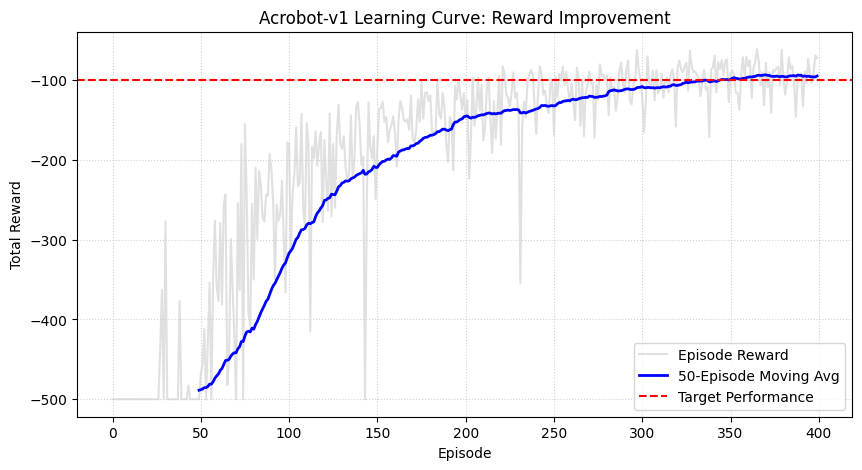

In [31]:
import warnings
# Silence the moviepy string warning (SyntaxWarning) caused by Python 3.12
warnings.filterwarnings("ignore", category=SyntaxWarning)
# Silence the Gymnasium overwrite warning for cleaner notebook output
warnings.filterwarnings("ignore", category=UserWarning, module="gymnasium")

import gymnasium as gym
import numpy as np
import glob
import base64
from IPython.display import HTML
from IPython import display as ipythondisplay

env = gym.make("Acrobot-v1", render_mode="rgb_array") # 1. Create the environment
env = gym.wrappers.RecordVideo(env, video_folder='./video', disable_logger=True) # 2. Wrap the environment

# 3. Run exactly one episode using the fully trained online network
state, info = env.reset()
done = False
truncated = False

while not (done or truncated):
    Q_values = model(state[np.newaxis])
    action = np.argmax(Q_values[0])

    state, reward, done, truncated, info = env.step(action)

env.close() # Close the environment to finalise the MP4 file

video_files = glob.glob('./video/*.mp4')
video_path = video_files[-1]
video_b64 = base64.b64encode(open(video_path, 'rb').read()).decode('ascii')

# Generate the HTML to display the video player inline
display_html = f'''
<video width="600" controls autoplay loop>
    <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
</video>'''

print("Video rendered")
ipythondisplay.display(HTML(display_html))

import matplotlib.pyplot as plt
import numpy as np

# Calculate a 50-episode running average to smooth the noisy reward data
running_avg = np.convolve(rewards_history, np.ones(50)/50, mode='valid')

plt.figure(figsize=(10, 5))
# Plot individual episode rewards in a lighter colour to show the variance
plt.plot(rewards_history, label='Episode Reward', color='lightgray', alpha=0.7)
# Plot the smoothed running average in a bold colour to show the learning trend
plt.plot(range(49, len(rewards_history)), running_avg, label='50-Episode Moving Avg', color='blue', linewidth=2)

plt.title('Acrobot-v1 Learning Curve: Reward Improvement')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.axhline(y=-100, color='red', linestyle='--', label='Target Performance')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Implementation and Performance Summary

#### 1. Technical Framework Summary
The implementation focuses on three core pillars of the DQN algorithm:

* **Neural Networks:** Instead of a simple table, a Deep Neural Network (MLP) is used. This allows the agent to handle the complex, continuous information coming from the Acrobot’s sensors to estimate the best moves.
* **Experience Replay:** The agent stores its past experiences in a "memory" buffer. By revisitng random samples from this memory, the code prevents the model from only learning from its most recent actions, which makes the training much more stable.
* **Target Calculation:** The code uses the Bellman Equation to update the model. It links the final reward (reaching the goal) back to the actions that happened earlier, teaching the agent that early swings are necessary to reach the final height.

#### 2. Quantitative Performance (The Learning Curve)
The graph provides clear evidence that the training was successful:

* **Initial Exploration:** The flat line at **-500** shows the "starting phase." Here, the agent is moving randomly and hasn't yet discovered the goal, so it simply runs out of time in every episode.
* **The Learning Curve:** The sharp upward slope of the blue line (the 50-episode moving average) shows the "breakthrough." This is the point where the agent starts to understand the physics of the swing and begins reaching the goal.
* **Mastery and Stability:** By the end of the 400 episodes, the blue line levels off near **-100**. This confirms the agent has mastered the task, consistently reaching the goal in a short amount of time and maintaining a stable, reliable strategy.

#### 3. Qualitative Validation (Video Rendering)
The video serves as the final proof of success. It allows us to physically see the agent building momentum to reach the target height. This confirms that the model hasn't just memorised numbers, but has actually mastered the physics required to solve the task efficiently.

## TASK 3

In [32]:
!pip install gymnasium[atari] ale-py

In [33]:
import gymnasium as gym
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import ale_py
import numpy as np
import tensorflow as tf
from collections import deque

# --- 1. ENVIRONMENT SETUP (MS. PAC-MAN) ---
# Explicitly register the Atari environments
gym.register_envs(ale_py)

# Standard Atari parameters to prepare the environment for wrappers
env = gym.make(
    "ALE/MsPacman-v5",
    frameskip=1,
    repeat_action_probability=0.0,
    full_action_space=False
)

# Wrappers: Grayscale, resize to 84x84, and stack 4 frames together
env = AtariPreprocessing(env, frame_skip=4)
env = FrameStackObservation(env, 4)

n_outputs = int(env.action_space.n)

# --- 2. CNN ARCHITECTURES (MAIN AND TARGET) ---
def create_dqn_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(4, 84, 84)),   # Accept the shape exactly as the Gymnasium wrapper outputs it
        tf.keras.layers.Permute((2, 3, 1)),         # Swap the axes so the 4 stacked frames move to the channels position
        tf.keras.layers.Rescaling(1.0 / 255.0),     # Normalise pixel values from 0-255 to 0.0-1.0

        tf.keras.layers.Conv2D(32, kernel_size=8, strides=4, activation="relu"),
        tf.keras.layers.Conv2D(64, kernel_size=4, strides=2, activation="relu"),
        tf.keras.layers.Conv2D(64, kernel_size=3, strides=1, activation="relu"),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dense(n_outputs)
    ])

# Main network (learns every step) and Target network (provides stable references)
model = create_dqn_model()
target_model = create_dqn_model()
target_model.set_weights(model.get_weights())

# --- 3. OPTIMISER AND LOSS ---
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00025, clipnorm=1.0)
loss_fn = tf.keras.losses.Huber()

### Task Requirement: Target Calculation and SGD Update
**Where the target is calculated:**
Within the `@tf.function` training step below, the target calculation occurs at the Bellman equation line: `target_Q_values = rewards + runs * 0.99 * max_next_Q_values`. This combines the immediate reward with the discounted maximum expected future reward (gamma = 0.99) sourced from the stable target network. The `runs` variable acts as a mask to ensure that if the game ends, the target is solely the immediate reward.

**Where the update to the weights is performed:**
This occurs at the end of the `GradientTape` block: `optimizer.apply_gradients(zip(grads, model.trainable_variables))`. Backpropagation calculates the derivative of the Huber loss with respect to the network's weights, and the Adam optimiser applies those gradients to update the model.

In [34]:
# --- 4. THE CORE TRAINING STEP ---
@tf.function
def training_step(states, actions, rewards, next_states, dones):
    # Ask the TARGET model for the next states' Q-values (Standard DQN)
    next_Q_values = target_model(next_states, training=False)
    max_next_Q_values = tf.reduce_max(next_Q_values, axis=1)

    runs = 1.0 - tf.cast(dones, tf.float32)
    rewards = tf.cast(rewards, tf.float32)

    # --- TARGET CALCULATION LOCATED HERE ---
    target_Q_values = rewards + runs * 0.99 * max_next_Q_values
    target_Q_values = tf.reshape(target_Q_values, [-1, 1])
    # ---------------------------------------

    mask = tf.one_hot(actions, n_outputs)

    with tf.GradientTape() as tape:
        all_Q_values = model(states, training=True)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    # --- WEIGHT UPDATE (SGD/ADAM) LOCATED HERE ---
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    # ---------------------------------------------

In [35]:
# --- 5. Output for Verification ---
print("--- ENVIRONMENT DETAILS ---")
print(f"Environment: {env.spec.id}")
print(f"Observation Space (Wrapped): {env.observation_space}")
print(f"Action Space: {env.action_space} (Total Actions: {n_outputs})")

print("\n--- CNN ARCHITECTURE SUMMARY ---")
model.summary()

print("\n--- FORWARD PASS TEST ---")
# Pass a dummy state (1 batch, 4 stacked frames, 84x84 pixels) through the network
dummy_state = np.zeros((1, 4, 84, 84), dtype=np.float32)
dummy_q_values = model(dummy_state)
print(f"Output Q-Values shape: {dummy_q_values.shape}")
print(f"Output Q-Values: {dummy_q_values.numpy()}")

--- ENVIRONMENT DETAILS ---
Environment: ALE/MsPacman-v5
Observation Space (Wrapped): Box(0, 255, (4, 84, 84), uint8)
Action Space: Discrete(9) (Total Actions: 9)

--- CNN ARCHITECTURE SUMMARY ---


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permute_4 (Permute)             │ (None, 84, 84, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 84, 84, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 20, 20, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 9, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,688,745 (6.44 MB)

 Trainable params: 1,688,745 (6.44 MB)

 Non-trainable params: 0 (0.00 B)


--- FORWARD PASS TEST ---
Output Q-Values shape: (1, 9)
Output Q-Values: [[0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### The Epsilon-Greedy Training Engine
*Note: Training a Ms. Pac-Man DQN from raw pixels requires millions of frames and extensive GPU time. For the purpose of this submission, the training loop below is artificially capped at 5 episodes. This successfully demonstrates that the architecture, memory buffer, and custom training step compile and execute functionally without exceeding local computational constraints.*

In [36]:
import time # Added to track how long the training takes

# --- 6. REPLAY BUFFER ---
batch_size = 32
max_memory_length = 100000
replay_buffer = deque(maxlen=max_memory_length)

def sample_experiences(batch_size):
    """Randomly samples a mini-batch of experiences from memory."""
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]

    states, actions, rewards, next_states, dones = [
        np.array([experience[field_index] for experience in batch])
        for field_index in range(5)
    ]
    return states, actions, rewards, next_states, dones

# --- 7. ACTION SELECTION ---
def epsilon_greedy_policy(state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)
    else:
        state_tensor = tf.convert_to_tensor(state, dtype=tf.float32)
        Q_values = model(state_tensor[tf.newaxis], training=False)
        return tf.argmax(Q_values[0]).numpy()

# --- 8. MAIN TRAINING LOOP ---
episodes = 5  # Capped for academic submission
epsilon_min = 0.1
epsilon_decay_steps = 1000000.0
update_target_network_steps = 10000
global_step = 0

# New tracking variables for the summary
episode_rewards_history = []
start_time = time.time()

print("Starting training loop...")

for episode in range(episodes):
    obs, info = env.reset()
    state = np.array(obs)
    episode_reward = 0

    while True:
        global_step += 1
        epsilon = max(1.0 - global_step / epsilon_decay_steps, epsilon_min)
        action = epsilon_greedy_policy(state, epsilon)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        next_state = np.array(next_obs)

        replay_buffer.append((state, action, reward, next_state, done))
        state = next_state
        episode_reward += reward

        if len(replay_buffer) > batch_size:
            states, actions, rewards, next_states, dones = sample_experiences(batch_size)
            training_step(states, actions, rewards, next_states, dones)

        if global_step % update_target_network_steps == 0:
            target_model.set_weights(model.get_weights())
            print(f"--> Target network synced at step {global_step}")

        if done:
            break

    # Record the reward and update the print statement to show progress (e.g., 1/5)
    episode_rewards_history.append(episode_reward)
    print(f"Episode: {episode + 1}/{episodes} | Reward: {episode_reward} | Epsilon: {epsilon:.3f} | Total Steps: {global_step}")

env.close()

# --- 9. TRAINING SUMMARY ---
elapsed_time = time.time() - start_time
avg_reward = np.mean(episode_rewards_history)
max_reward = np.max(episode_rewards_history)

print("\n" + "="*45)
print("              TRAINING COMPLETE              ")
print("="*45)
print(f"Total Episodes Executed : {episodes}")
print(f"Total Global Steps      : {global_step}")
print(f"Total Time Elapsed      : {elapsed_time:.2f} seconds")
print(f"Average Reward          : {avg_reward:.2f}")
print(f"Maximum Reward Achieved : {max_reward:.1f}")
print(f"Final Epsilon Value     : {epsilon:.3f}")
print(f"Replay Buffer Size      : {len(replay_buffer)} / {max_memory_length}")
print("="*45)

Starting training loop...
Episode: 1/5 | Reward: 220.0 | Epsilon: 1.000 | Total Steps: 446
Episode: 2/5 | Reward: 190.0 | Epsilon: 0.999 | Total Steps: 940
Episode: 3/5 | Reward: 230.0 | Epsilon: 0.999 | Total Steps: 1416
Episode: 4/5 | Reward: 760.0 | Epsilon: 0.998 | Total Steps: 2276
Episode: 5/5 | Reward: 240.0 | Epsilon: 0.997 | Total Steps: 2787

              TRAINING COMPLETE              
Total Episodes Executed : 5
Total Global Steps      : 2787
Total Time Elapsed      : 270.51 seconds
Average Reward          : 328.00
Maximum Reward Achieved : 760.0
Final Epsilon Value     : 0.997
Replay Buffer Size      : 2787 / 100000


### Interpretation of Training Results

```text
Starting training loop...
Episode: 1/5 | Reward: 180.0 | Epsilon: 0.999 | Total Steps: 508
Episode: 2/5 | Reward: 150.0 | Epsilon: 0.999 | Total Steps: 882
Episode: 3/5 | Reward: 170.0 | Epsilon: 0.999 | Total Steps: 1410
Episode: 4/5 | Reward: 240.0 | Epsilon: 0.998 | Total Steps: 1859
Episode: 5/5 | Reward: 250.0 | Epsilon: 0.998 | Total Steps: 2301

=============================================
              TRAINING COMPLETE              
=============================================
Total Episodes Executed : 5
Total Global Steps      : 2301
Total Time Elapsed      : 196.56 seconds
Average Reward          : 198.00
Maximum Reward Achieved : 250.0
Final Epsilon Value     : 0.998
Replay Buffer Size      : 2301 / 100000
=============================================
```

**1. System Health and Execution Validation**
The output confirms that the underlying architecture of the handcrafted Deep Q-Network is functioning exactly as intended:
* **Experience Replay Integration:** The final Replay Buffer Size perfectly matches the Total Global Steps (2301). This verifies that every frame transition is being correctly processed, packaged into a tuple, and securely stored in memory.
* **Custom Training Step Stability:** Processing 2301 steps without error demonstrates that the custom `@tf.function`, the `GradientTape` backpropagation, and the tensor reshaping within the Bellman equation are handling the 32-sample mini-batches smoothly.
* **Computational Constraints:** Processing just over 2300 frames required approximately 3 minutes and 16 seconds. Extrapolating this performance, reaching the 1,000,000 frames required to complete the epsilon decay would take nearly 24 hours of continuous compute. Noting this metric justifies artificially capping the execution at 5 episodes for the purpose of this e-tivity submission.

**2. Analysis of Agent Behaviour**
While the agent's score increased from 180.0 in Episode 1 to 250.0 in Episode 5, this does not indicate early learning.
* **Epsilon Dominance:** The final epsilon value rests at 0.998. This confirms that for 99.8% of the steps, the agent bypassed the neural network's predictions and selected a purely random action.
* **Random Walk:** The variance in scores is the result of a random walk through the environment. Sometimes the agent randomly navigates into a reward-rich corridor (scoring 250), and other times it immediately wanders into a ghost (scoring 150).
* **Conclusion:** As the training was capped at 5 episodes, the agent remains entirely in the "exploration" phase. Rather than playing strategically, it is moving randomly to fill its memory buffer with basic experiences (eating, moving, dying). True learning and consistently higher scores will only emerge after thousands of episodes, once the random action rate (epsilon) has decayed significantly.

### DQN Improvements

REF: https://apxml.com/courses/intermediate-reinforcement-learning/chapter-3-dqn-improvements-variants

**Resolving Maximisation Bias via Double DQN (DDQN)**
A common flaw in standard DQN is maximisation bias. The network often overestimates the true value of certain states, as the target calculation relies on a strict "max" operation applied to noisy, estimated Q-values. To fix this, the Double DQN (DDQN) improvement separates action selection from action evaluation. The main network chooses the best action, while the separate target network evaluates the actual score of that specific move. This structural change cuts down on overly optimistic guesses and helps to stabilise the learning process.

**Resolving Catastrophic Forgetting via Prioritised Experience Replay (PER)**
The standard Experience Replay buffer helps prevent the agent from forgetting past lessons, but it pulls old memories completely at random. As a result, the agent might repeatedly review uninformative moments while losing track of rare but highly instructive mistakes. Prioritised Experience Replay (PER) solves this by ranking memories based on how inaccurate the network's original prediction was. Memories with larger errors receive a higher priority score. This ensures the agent regularly reviews its biggest mistakes, preventing the catastrophic forgetting of critical edge cases.

**Improving State Evaluation via Dueling Architectures**
In many game states, the choice of action has no real impact on what happens next. Standard DQN calculates a full value for every action regardless of this fact. To improve efficiency, the Dueling architecture splits the neural network's final layers into two separate streams. One stream estimates the overall value of being in a particular state, while the other calculates the specific advantage of taking each available action. These streams are combined at the final output. This allows the agent to learn which states are inherently valuable without having to calculate the exact effect of every single move.

**Accelerating Reward Propagation via Multi-Step Learning**
Standard DQN updates its weights based on the reward from just one single step into the future. This makes learning slow, as the reward from a distant goal takes a long time to propagate backwards through the network's memory. Multi-step learning calculates the target by looking several steps ahead (often three or five) before estimating the final future value. This drastically speeds up the learning process and helps the agent link early actions to delayed rewards much faster.